In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Individual Caches

In [2]:
compression_ratios = [2, 3, 4, 8]

plot_data = {
    "K": {
        "Mistral-7B": {
            "RULER": {
                "SVD":       [97.9, 97.6, 97.0, None],
                "KMeans":    [97.7, 97.5, 95.1, None],
                "KMeans PH": [97.6, 97.2, 95.3, None],
                "xKV-4":     [97.9, 98.0, 98.0, 97.2],
            },
            "LongBench": {
                "SVD":       [98.0, 94.8, 90.3, None],
                "KMeans":    [98.1, 96.8, 94.3, None],
                "KMeans PH": [98.3, 95.9, 93.7, None],
                "xKV-4":     [100.6, 100.3, 100.0, 98.3],
            },
        },
        "Llama3.1-8B": {
            "RULER": {
                "SVD":       [99.1, 97.6, 64.5, None],
                "KMeans":    [99.4, 97.5, 77.2, None],
                "KMeans PH": [99.7, 97.8, 77.8, None],
                "xKV-4":     [100.0, 99.7, 99.6, 97.8],
            },
            "LongBench": {
                "SVD":       [91.1, 85.5, 77.4, None],
                "KMeans":    [94.3, 90.9, 85.5, None],
                "KMeans PH": [96.2, 90.8, 86.8, None],
                "xKV-4":     [96.3, 94.9, 93.4, 91.2],
            },
        },
    },

    "V": {
        "Mistral-7B": {
            "RULER": {
                "SVD":       [97.6, 95.6, 84.5, None],
                "KMeans":    [97.6, 96.7, 94.1, None],
                "KMeans PH": [97.7, 97.0, 94.6, None],
                "xKV-4":     [97.9, 97.9, 97.8, 96.0],
            },
            "LongBench": {
                "SVD":       [98.8, 92.3, 85.9, None],
                "KMeans":    [99.0, 97.3, 93.8, None],
                "KMeans PH": [98.5, 96.6, 95.1, None],
                "xKV-4":     [99.7, 99.8, None, None],
            },
        },
        "Llama3.1-8B": {
            "RULER": {
                "SVD":       [99.3, 93.6, 74.2, None],
                "KMeans":    [99.3, 98.6, 92.7, None],
                "KMeans PH": [99.5, 98.7, 94.0, None],
                "xKV-4":     [99.9, 99.7, 99.3, 96.0],
            },
            "LongBench": {
                "SVD":       [89.4, 82.0, 76.9, None],
                "KMeans":    [94.2, 90.2, 85.9, None],
                "KMeans PH": [95.0, 93.8, 89.5, None],
                "xKV-4":     [95.0, 95.3, 95.8, 88.3],
            },
        },
    },
}

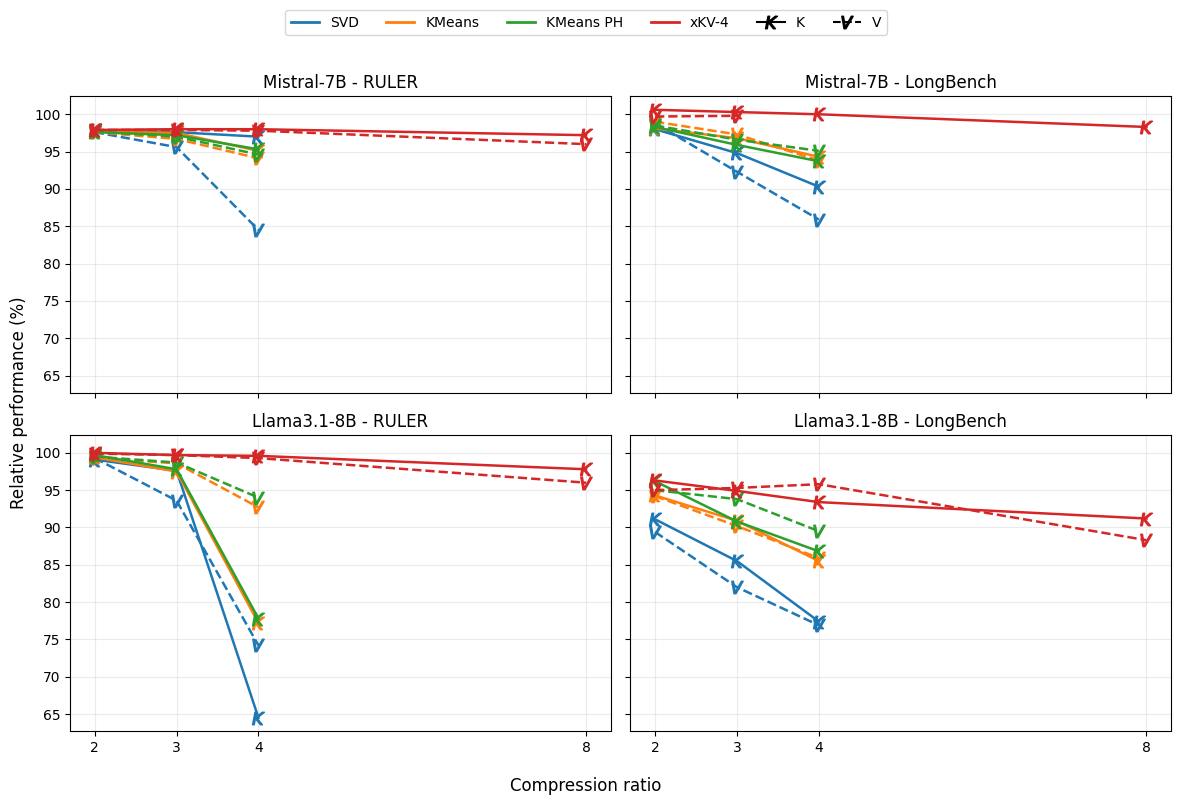

In [3]:
from matplotlib.lines import Line2D

models = ["Mistral-7B", "Llama3.1-8B"]
benchmarks = ["RULER", "LongBench"]
methods = ["SVD", "KMeans", "KMeans PH", "xKV-4"]
colors = dict(zip(methods, plt.get_cmap("tab10").colors))
markers = {"K": "$K$", "V": "$V$"}
linestyles = {"K": "-", "V": "--"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, (model, benchmark) in zip(
    axes.flat,
    ((model, benchmark) for model in models for benchmark in benchmarks),
):
    for method in methods:
        for cache_type in ("K", "V"):
            values = plot_data[cache_type][model][benchmark][method]
            ax.plot(
                compression_ratios,
                [np.nan if value is None else value for value in values],
                color=colors[method],
                linestyle=linestyles[cache_type],
                marker=markers[cache_type],
                markersize=9,
                linewidth=1.8,
            )

    ax.set_title(f"{model} - {benchmark}")
    ax.set_xticks(compression_ratios)
    ax.grid(alpha=0.25)

fig.supxlabel("Compression ratio")
fig.supylabel("Relative performance (%)")

method_handles = [
    Line2D([0], [0], color=colors[method], linewidth=2, label=method)
    for method in methods
]
cache_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=linestyles[cache_type],
        marker=markers[cache_type],
        markersize=9,
        label=cache_type,
    )
    for cache_type in ("K", "V")
]
fig.legend(
    handles=method_handles + cache_handles,
    loc="upper center",
    ncol=len(method_handles) + len(cache_handles),
    bbox_to_anchor=(0.5, 1.0),
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()